# Sprint 2 : Construction d’un premier réseau de neurones
### Projet : Prédiction du risque de diabète - BRFSS 2015
---
**Formation** : FISE A4 Data & IA - CESI Bordeaux  
**Dataset** : `diabetes_012_health_indicators_BRFSS2015.csv`  
**Livrable** : Sprint 2 : Modèles de prédiction et évaluations


## Sommaire

1. Imports et configuration
2. Chargement des datasets
3. Justification des choix d'architecture
4. Construction des modèles
5. Entraînement
6. Évaluation des modèles
7. Optimisation avec Keras Tuner
8. Analyse du seuil de décision
9. Comparaison finale et conclusion

## 1. Imports et configuration

In [1]:
# Suppression des avertissements non critiques
import warnings
warnings.filterwarnings('ignore')

# Librairies de base
import numpy as np
import pandas as pd
import time
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=tout, 1=info, 2=warning, 3=error seulement

DATA_PATH = 'data/processed/'

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

#import keras_tuner as kt

# Métriques d'évaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Configuration graphique
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)

# Graine aléatoire pour la reproductibilité des résultats
RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print('TensorFlow version :', tf.__version__)
print('Imports OK')

TensorFlow version : 2.21.0
Imports OK


## 2. Chargement des datasets

In [2]:
# Features
X_train = pd.read_csv(os.path.join(DATA_PATH, 'X_train.csv'))
X_val   = pd.read_csv(os.path.join(DATA_PATH, 'X_val.csv'))
X_test  = pd.read_csv(os.path.join(DATA_PATH, 'X_test.csv'))

# Labels
y_train = pd.read_csv(os.path.join(DATA_PATH, 'y_train.csv'))
y_val   = pd.read_csv(os.path.join(DATA_PATH, 'y_val.csv'))
y_test  = pd.read_csv(os.path.join(DATA_PATH, 'y_test.csv'))

# Aperçu des dimensions
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(305668, 18)
(38052, 18)
(38052, 18)
(305668, 1)
(38052, 1)
(38052, 1)


## 3. Justification des choix d'architecture

### Analyse du problème
Avant de construire le réseau, il faut identifier les caractéristiques du problème qui comptent le plus.
La tâche à réaliser est une classification binaire, c'est-à-dire que la sortie est un seul neurone avec une fonction d'activation que l'on choisira plus tard dans ce livrable pour construire les modèles.  


### Non-linéarité des données
Lors de l'analyse exploratoire du Sprint 1, nous avons relevé que les variables n'ont pas de relation linéaire avec la variable cible, c'est-à-dire que les variables n'évoluent pas les unes en fonction des autres de façon ordonnée. Il faut donc exclure l'idée de créer un modèle de prédiction linéaire.


### Déséquilibre des classes
L'analyse du Sprint 1 a aussi montrer que la repartition dans le dataset est d'environ 86% de non-diabétiques et 14% de diabétiques.

Pour évaluer nos modèles, on ne peut pas se contenter de l'accuracy. L'accuracy mesure le pourcentage de bonnes prédictions. Le problème c'est que même si on a rééquilibré le jeu d'entraînement avec **SMOTE**, le jeu de validation et de test gardent leur distribution réelle : environ 86% de non-diabétiques contre 14% de diabétiques. Un modèle qui prédirait toujours "non diabétique" aurait donc 86% d'accuracy sans avoir rien appris.

C'est pourquoi on utilise la **ROC-AUC** comme métrique principale. La ROC-AUC mesure la capacité du modèle à distinguer les diabétiques des non-diabétiques, quelle que soit la distribution des classes. Une valeur de 1 signifie que le modèle sépare parfaitement les deux classes, une valeur de 0.5 équivaut à une prédiction aléatoire. Elle est donc bien plus fiable que l'accuracy dans notre cas.

On observe aussi le **recall**, dans un contexte médical, rater un diabétique est plus grave que signaler un faux positif. Un faux positif mènera à des analyses supplémentaires, ce qui est acceptable. Un faux négatif, lui, laisse un patient diabétique sans prise en charge.

### Contrainte médicale, l'importance des faux négatifs
Un des graphes d'analyse les plus importants est la matrice de confusion à 4 cases :
- **TN** (Vrai Négatif) : sont les non-diabétiques bien classés
- **FP** (Faux Positif) : sont les non-diabétiques classés diabétiques. Le patient fera des analyses supplémentaires, ce qui est acceptable
- **FN** (Faux Négatif) : sont les diabétiques non détectés, c'est le cas le plus dangereux car le patient ne sera pas pris en charge
- **TP** (Vrai Positif) : sont les diabétiques bien détectés, c'est ce qu'on cherche à maximiser

L'objectif de cette matrice est de minimiser les FN et donc de maximiser le recall.

### Équilibre entre performance et explicabilité
Plus le réseau de neurone est profond (plusieurs couche de fonctions) et plus il est difficile d'expliquer ses décisions. On cherche alors a realiser un modèle efficace mais pas inutilement complexe.

### Les deux architectures

Nous allons dans ce livrable réaliser deux modèles. Un modèle A très simple dont on observera les performances, et ensuite un modèle B plus complexe dont nous comparerons les performances au modèle A.

**Modèle A : Simple**  
Il sera constitué de deux couches cachées, c'est la couche intermédiaire entre l'entrée et la sortie, là où le réseau apprend à détecter des patterns dans les données. 
L'objectif est de créer un premier modèle de prédiction fonctionnel pour comprendre les mécanismes de base avant de passer à une architecture plus complexe.  
On s'attend à ce que ses performances soient limitées, mais c'est ce résultat qui nous servira de référence pour mesurer l'apport du Modèle B.

**Modèle B : Plus profond**  
Il sera constitué de plusieurs couches cachées (plus de deux), dont le nombre exact sera défini lors de la construction. 
On y ajoutera des mécanismes pour éviter que le modèle apprenne trop bien les données d'entraînement au point de ne plus généraliser sur de nouvelles données.  
C'est ce modèle qu'on cherchera à optimiser s'il donne de meilleurs résultats que le Modèle A.

## 4. Construction des modèles

### 4.1 Modèle A : Simple

Le Modèle A est notre architecture de référence. Il est volontairement simple, c'est à dire deux couches cachées avec peu de neurones. 

En entrée, le réseau reçoit les 18 variables de santé de chaque patient.  
Ces informations traversent d'abord une première couche de 16 neurones, puis une deuxième de 8 neurones, où le réseau va progressivement apprendre à combiner les variables entre elles pour mieux prédire le risque de diabète.  
En sortie, un seul neurone produit une probabilité entre 0 et 1 et plus elle est proche de 1, plus le patient a de risques d'être diabétique.

#### 4.1.1 Les fonctions d'activation

Les fonctions d'activation sont des fonctions mathématiques appliquées à la sortie de chaque neurone. Sans elles, le réseau ne serait qu'une succession de calculs linéaires et ne pourrait pas apprendre des relations complexes entre les variables.

- Le **ReLU** (Rectified Linear Unit) est la fonction la plus utilisée pour les couches cachées.  
Son principe est simple, si la valeur est négative elle renvoie 0, sinon elle renvoie la valeur telle quelle.  
On l'utilise car elle permet au réseau d'ignorer les signaux non pertinents (en renvoyant 0) et de laisser passer uniquement les informations utiles, ce qui aide le modèle à mieux apprendre les relations entre les variables.

- Le **Sigmoid** est la fonction que l'on utilise uniquement sur la couche de sortie.  
Elle transforme n'importe quelle valeur en un nombre entre 0 et 1, ce qui correspond exactement à une probabilité.  
C'est donc le meilleur choix pour notre classification binaire puisque ainsi, le réseau nous dit "cette personne a X% de chances d'être diabétique".

In [3]:
input_dim = X_train.shape[1]  # nombre de features en entrée : 18

def build_model_A(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(16, activation='relu', kernel_regularizer=l2(1e-4)),  # 1ère couche cachée : 16 neurones
        Dense(8, activation='relu', kernel_regularizer=l2(1e-4)),   # 2ème couche cachée : 8 neurones
        Dense(1, activation='sigmoid')                               # sortie : probabilité entre 0 et 1
    ], name="model_A")
    
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model_A = build_model_A(input_dim)
model_A.summary()

Model: "model_A"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 449 (1.75 KB)

 Trainable params: 449 (1.75 KB)

 Non-trainable params: 0 (0.00 B)

#### 4.1.2 Rappel

Une couche **Dense** est une couche où chaque neurone est connecté à tous les neurones de la couche précédente. Par exemple Dense(8, relu) signifie une couche de 8 neurones avec la fonction d'activation ReLU.

L'optimizer **Adam** est l'algorithme qui ajuste les poids du modèle après chaque erreur. On l'utilise car il adapte automatiquement la vitesse d'apprentissage pour chaque paramètre, ce qui le rend plus efficace que des algorithmes plus basiques sur des datasets de grande taille comme le nôtre.

La loss **binary_crossentropy** mesure l'écart entre la probabilité prédite par le modèle et la vraie classe (0 ou 1). On l'utilise car elle est mathématiquement adaptée aux problèmes où la sortie est une probabilité entre 0 et 1.

Le **kernel_regularizer = l2(1e-4)** pénalise les poids trop élevés pendant l'entraînement pour éviter que le modèle ne s'adapte trop aux données d'entraînement au détriment de la généralisation.

Le **biais** est un paramètre supplémentaire ajouté automatiquement par Keras à chaque couche Dense. il permet au modèle de décaler sa sortie indépendamment des entrées.  
Sans lui, le réseau perdrait une grande partie de sa flexibilité car si toutes les entrées d'un neurone valaient 0, sa sortie serait forcément 0 quels que soient ses poids.  
Le biais lui permet de produire une sortie non nulle dans ce cas, ce qui lui donne plus de liberté pour s'adapter aux données.

Le choix de **16 puis 8 puis 1 neurones** suit une logique de compression progressive de l'information, inspirée des puissances de 2.  
À chaque couche, le réseau est forcé de résumer ce qu'il a appris avec moins de neurones, comme un entonnoir qui garde uniquement les informations utiles pour la prédiction finale. 

### Configuration de l'entraînement

Avant de lancer l'entraînement, on définit deux éléments importants : l'EarlyStopping et les hyperparamètres de base.

Le **EarlyStopping** surveille la loss sur la validation à chaque epoch. Si elle ne s'améliore pas pendant 10 epochs de suite, l'entraînement s'arrête automatiquement et les meilleurs poids sont restaurés.  
Cela évite que le modèle apprenne trop bien les données d'entraînement au point de ne plus généraliser.

**Les hyperparamètres de base :**

- L'**EPOCHS** est fixé à 100, c'est le nombre maximum de fois que le modèle va parcourir toutes les données d'entraînement. En pratique EarlyStopping s'arrêtera bien avant.

- Le **BATCH_SIZE** est fixé à 64, ce qui signifie qu'au lieu de traiter toutes les données d'un coup, le modèle les traite par paquets de 64 lignes. Après chaque paquet il ajuste ses poids.

In [4]:
early_stop = EarlyStopping(
    monitor = 'val_loss',        # surveille la loss sur la validation
    patience = 10,               # attend 10 epochs sans amélioration avant de stopper
    restore_best_weights = True  # remet les poids du meilleur epoch
)

EPOCHS     = 50  # nombre maximum d'epochs
BATCH_SIZE = 64   # nombre de lignes traitées par paquet

#### 4.1.3 Entraînement du Modèle A

Maintenant on lance l'entraînement. Le modèle va apprendre sur X_train et on surveille ses performances sur X_val à chaque epoch grâce à l'EarlyStopping.

In [5]:
history_A = model_A.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),  # surveillance sur la validation
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,           
    callbacks = [early_stop],          # active l'EarlyStopping à chaque fin d'epoch
    verbose = 1                        # affiche la loss et l'accuracy à chaque epoch
)

Epoch 1/50
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7402 - loss: 0.5217 - val_accuracy: 0.6855 - val_loss: 0.5576
Epoch 2/50
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7476 - loss: 0.5104 - val_accuracy: 0.6865 - val_loss: 0.5548
Epoch 3/50
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7485 - loss: 0.5090 - val_accuracy: 0.6849 - val_loss: 0.5559
Epoch 4/50
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7491 - loss: 0.5083 - val_accuracy: 0.6849 - val_loss: 0.5577
Epoch 5/50
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7498 - loss: 0.5078 - val_accuracy: 0.6855 - val_loss: 0.5580
Epoch 6/50
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7499 - loss: 0.5073 - val_accuracy: 0.6860 - val_loss: 0.5576
Epoch 7/50
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.7498 - loss: 0.5069 - val_accuracy: 0.6857 - val_loss: 0.5565
Epoch 8/50
4777/4777 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7497 - loss: 0.5066 - 

#### 4.1.4 Évaluation sur la validation

On évalue le Modèle A sur le jeu de validation avec un seuil de 0.5 par défaut.

In [6]:
# Prédictions : le modèle renvoie des probabilités entre 0 et 1
y_prob_A = model_A.predict(X_val, verbose=0).ravel()

# Seuil de décision : si probabilité >= 0.5 → diabétique, sinon → non diabétique
THRESHOLD = 0.5
y_pred_A = (y_prob_A >= THRESHOLD).astype(int)

# Calcul des métriques d'évaluation
acc_A  = accuracy_score(y_val,  y_pred_A)
prec_A = precision_score(y_val, y_pred_A, zero_division=0)
rec_A  = recall_score(y_val,    y_pred_A, zero_division=0)  # priorité : minimiser les FN
f1_A   = f1_score(y_val,        y_pred_A, zero_division=0)
auc_A  = roc_auc_score(y_val,   y_prob_A)  # métrique principale : insensible au déséquilibre des classes

# Décomposition de la matrice de confusion en 4 valeurs
cm_A = confusion_matrix(y_val, y_pred_A)
tn_A, fp_A, fn_A, tp_A = cm_A.ravel()

print(f'Résultats Modèle A : Validation (seuil = {THRESHOLD})')
print(f'  Accuracy  : {acc_A:.4f}')
print(f'  Precision : {prec_A:.4f}')
print(f'  Recall    : {rec_A:.4f}')
print(f'  F1-score  : {f1_A:.4f}')
print(f'  ROC-AUC   : {auc_A:.4f}')
print(f'\n  TN={tn_A}  FP={fp_A}')
print(f'  FN={fn_A}  TP={tp_A}')
print(f'\n  Résultat : {fn_A} diabétiques non détectés')  # FN : cas les plus dangereux

Résultats Modèle A : Validation (seuil = 0.5)
  Accuracy  : 0.6865
  Precision : 0.2745
  Recall    : 0.7610
  F1-score  : 0.4035
  ROC-AUC   : 0.7895

  TN=22087  FP=10663
  FN=1267  TP=4035

  Résultat : 1267 diabétiques non détectés


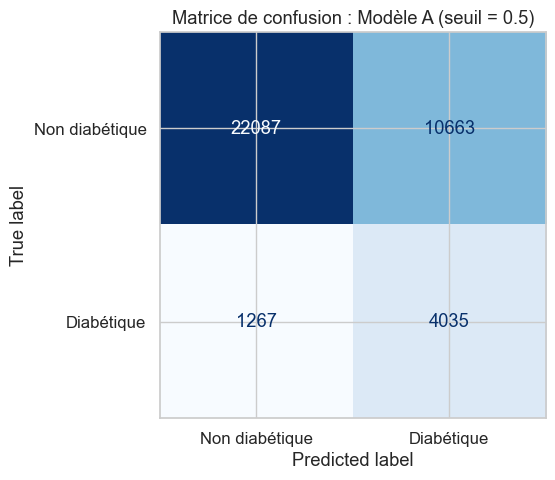

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_A,
                               display_labels=['Non diabétique', 'Diabétique'])
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
ax.set_title('Matrice de confusion : Modèle A (seuil = 0.5)')
plt.tight_layout()
plt.show()